Loading data...
  X_test : (584, 30, 36)
  y_test : (584,)

Loading models...


  LSTM loaded
  GRU  loaded

Predicting...

ACCURACY COMPARISON
  Model                  Accuracy   F1 (weighted)
  ------------------------------------------------
  LSTM                     0.7705          0.7719
  GRU                      0.7466          0.7544
  Ensemble (LSTM+GRU)      0.7808          0.7837

  Best model : Ensemble

ENSEMBLE — PER CLASS REPORT
              precision    recall  f1-score   support

     Waiting       0.86      0.76      0.81       257
    Hesitant       0.48      0.64      0.55        33
   Committed       0.83      0.89      0.86       118
  Distracted       0.60      0.84      0.70        32
  Aggressive       0.85      0.85      0.85        93
     Jaywalk       0.59      0.57      0.58        51

    accuracy                           0.78       584
   macro avg       0.70      0.76      0.72       584
weighted avg       0.79      0.78      0.78       584

PER CLASS ACCURACY — ALL MODELS
  State              LSTM       GRU    Ensemble
  ------

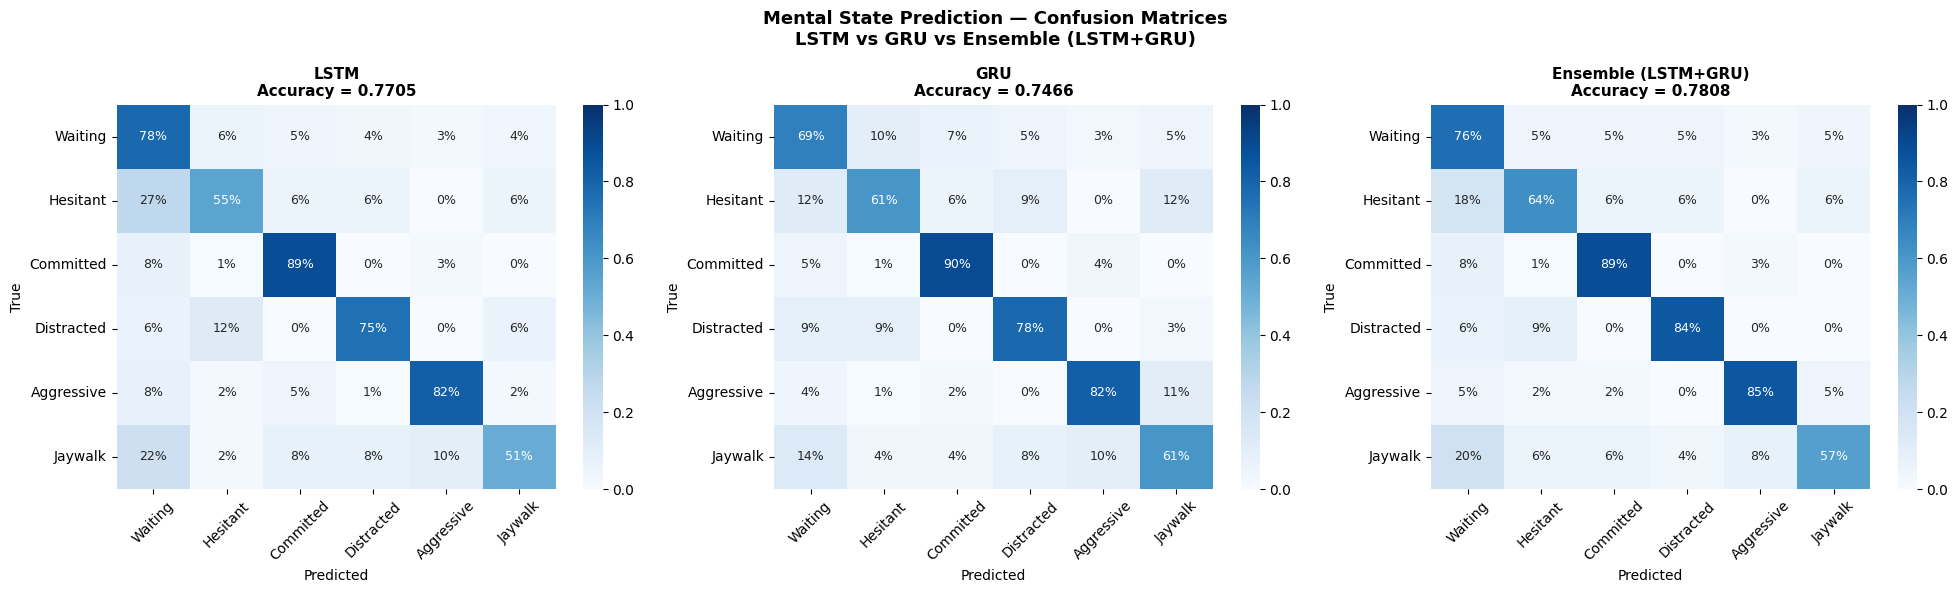


Plot saved → /content/drive/MyDrive/PIE/plots/ensemble_confusion_matrices.png


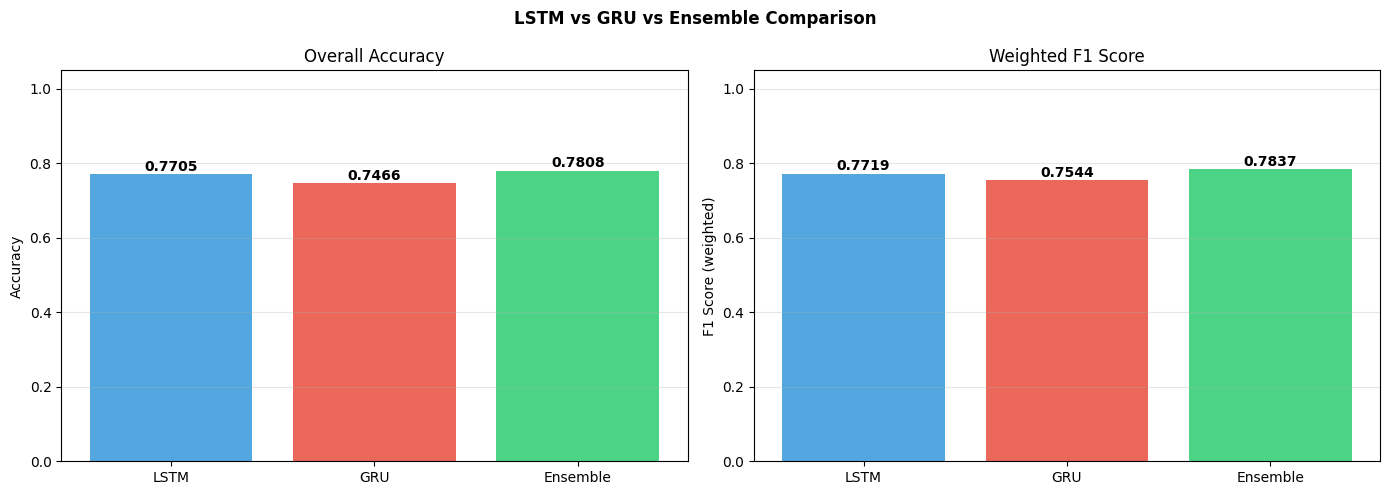

Plot saved → /content/drive/MyDrive/PIE/plots/ensemble_comparison_bar.png

SUMMARY
  LSTM     accuracy : 0.7705   F1 : 0.7719
  GRU      accuracy : 0.7466   F1 : 0.7544
  Ensemble accuracy : 0.7808   F1 : 0.7837

  Ensemble gain over LSTM : +1.03%
  Ensemble gain over GRU  : +3.42%


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
import joblib

# ══════════════════════════════════════════════════════════════
# PATHS
# ══════════════════════════════════════════════════════════════
MODELS_DIR  = '/content/drive/MyDrive/PIE/models'
FEATURES_DIR= '/content/drive/MyDrive/PIE/features'
PLOTS_DIR   = '/content/drive/MyDrive/PIE/plots'
import os; os.makedirs(PLOTS_DIR, exist_ok=True)

LABEL_NAMES = {
    0:'Waiting', 1:'Hesitant',  2:'Committed',
    3:'Distracted', 4:'Aggressive', 5:'Jaywalk'
}

# ══════════════════════════════════════════════════════════════
# LOAD DATA
# ══════════════════════════════════════════════════════════════
print('Loading data...')
X_test = np.load(f'{FEATURES_DIR}/X_test.npy')
y_test = np.load(f'{FEATURES_DIR}/y_test.npy')
print(f'  X_test : {X_test.shape}')
print(f'  y_test : {y_test.shape}')

# ══════════════════════════════════════════════════════════════
# LOAD MODELS
# ══════════════════════════════════════════════════════════════
print('\nLoading models...')
lstm_model = keras.models.load_model(
    f'{MODELS_DIR}/lstm_mental_state_best.h5'
)
gru_model  = keras.models.load_model(
    f'{MODELS_DIR}/gru_mental_state_best.h5'
)
print('  LSTM loaded')
print('  GRU  loaded')

# ══════════════════════════════════════════════════════════════
# PREDICT
# ══════════════════════════════════════════════════════════════
print('\nPredicting...')

# LSTM
lstm_probs = lstm_model.predict(X_test, verbose=0, batch_size=256)
lstm_pred  = np.argmax(lstm_probs, axis=1)

# GRU
gru_probs  = gru_model.predict(X_test,  verbose=0, batch_size=256)
gru_pred   = np.argmax(gru_probs,  axis=1)

# Ensemble — simple average
ensemble_probs = (lstm_probs + gru_probs) / 2.0
ensemble_pred  = np.argmax(ensemble_probs, axis=1)

# ══════════════════════════════════════════════════════════════
# METRICS
# ══════════════════════════════════════════════════════════════
lstm_acc     = accuracy_score(y_test, lstm_pred)
gru_acc      = accuracy_score(y_test, gru_pred)
ensemble_acc = accuracy_score(y_test, ensemble_pred)

lstm_f1      = f1_score(y_test, lstm_pred,     average='weighted')
gru_f1       = f1_score(y_test, gru_pred,      average='weighted')
ensemble_f1  = f1_score(y_test, ensemble_pred, average='weighted')

print('\n' + '='*55)
print('ACCURACY COMPARISON')
print('='*55)
print(f'  {"Model":<20} {"Accuracy":>10}  {"F1 (weighted)":>14}')
print(f'  {"-"*48}')
print(f'  {"LSTM":<20} {lstm_acc:>10.4f}  {lstm_f1:>14.4f}')
print(f'  {"GRU":<20} {gru_acc:>10.4f}  {gru_f1:>14.4f}')
print(f'  {"Ensemble (LSTM+GRU)":<20} {ensemble_acc:>10.4f}  {ensemble_f1:>14.4f}')
print(f'\n  Best model : '
      f'{"Ensemble" if ensemble_acc >= max(lstm_acc,gru_acc) else "Single model"}')

# ── Per class report ────────────────────────────────────────
print('\n' + '='*55)
print('ENSEMBLE — PER CLASS REPORT')
print('='*55)
print(classification_report(
    y_test, ensemble_pred,
    target_names=[LABEL_NAMES[i] for i in range(6)]
))

# ── Per class accuracy ──────────────────────────────────────
print('PER CLASS ACCURACY — ALL MODELS')
print(f'  {"State":<14} {"LSTM":>8}  {"GRU":>8}  {"Ensemble":>10}')
print(f'  {"-"*46}')
for cls in range(6):
    mask = y_test == cls
    if mask.sum() == 0: continue
    la = (lstm_pred[mask]     == cls).mean()
    ga = (gru_pred[mask]      == cls).mean()
    ea = (ensemble_pred[mask] == cls).mean()
    print(f'  {LABEL_NAMES[cls]:<14} {la:>8.3f}  {ga:>8.3f}  {ea:>10.3f}')

# ══════════════════════════════════════════════════════════════
# PLOTS
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    'Mental State Prediction — Confusion Matrices\n'
    'LSTM vs GRU vs Ensemble (LSTM+GRU)',
    fontsize=13, fontweight='bold'
)

class_names = [LABEL_NAMES[i] for i in range(6)]

for ax, pred, title, acc in zip(
    axes,
    [lstm_pred, gru_pred, ensemble_pred],
    ['LSTM', 'GRU', 'Ensemble (LSTM+GRU)'],
    [lstm_acc, gru_acc, ensemble_acc]
):
    cm     = confusion_matrix(y_test, pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_pct, ax=ax,
        annot=True, fmt='.0%',
        cmap='Blues', vmin=0, vmax=1,
        xticklabels=class_names,
        yticklabels=class_names,
        annot_kws={'size': 9}
    )
    ax.set_title(f'{title}\nAccuracy = {acc:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True',      fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/ensemble_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'\nPlot saved → {PLOTS_DIR}/ensemble_confusion_matrices.png')

# ── Bar chart comparison ─────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('LSTM vs GRU vs Ensemble Comparison',
              fontsize=12, fontweight='bold')

models      = ['LSTM', 'GRU', 'Ensemble']
accuracies  = [lstm_acc,  gru_acc,  ensemble_acc]
f1_scores_  = [lstm_f1,   gru_f1,   ensemble_f1]
colors      = ['#3498db', '#e74c3c', '#2ecc71']

# Accuracy bar
ax = axes2[0]
bars = ax.bar(models, accuracies, color=colors, alpha=0.85)
ax.set_ylim([0, 1.05])
ax.set_ylabel('Accuracy')
ax.set_title('Overall Accuracy')
for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontsize=10,
            fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# F1 bar
ax = axes2[1]
bars = ax.bar(models, f1_scores_, color=colors, alpha=0.85)
ax.set_ylim([0, 1.05])
ax.set_ylabel('F1 Score (weighted)')
ax.set_title('Weighted F1 Score')
for bar, val in zip(bars, f1_scores_):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontsize=10,
            fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/ensemble_comparison_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved → {PLOTS_DIR}/ensemble_comparison_bar.png')

# ══════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ══════════════════════════════════════════════════════════════
print('\n' + '='*55)
print('SUMMARY')
print('='*55)
print(f'  LSTM     accuracy : {lstm_acc:.4f}   F1 : {lstm_f1:.4f}')
print(f'  GRU      accuracy : {gru_acc:.4f}   F1 : {gru_f1:.4f}')
print(f'  Ensemble accuracy : {ensemble_acc:.4f}   F1 : {ensemble_f1:.4f}')
gain_over_lstm = (ensemble_acc - lstm_acc) * 100
gain_over_gru  = (ensemble_acc - gru_acc)  * 100
print(f'\n  Ensemble gain over LSTM : {gain_over_lstm:+.2f}%')
print(f'  Ensemble gain over GRU  : {gain_over_gru:+.2f}%')

In [7]:
from sklearn.metrics import cohen_kappa_score
import numpy as np

# Calculate kappa score using predicted class labels from previous cells
kappa = cohen_kappa_score(lstm_pred, gru_pred)
print(f"Kappa score: {kappa:.4f}")

# Threshold decision for final_predictions (which will be a 1D array of class labels)
if kappa > 0.82:
    print("→ HIGH CORRELATION: Use single best model (LSTM)")
    final_predictions = lstm_pred  # Use LSTM's predicted class labels
elif kappa < 0.6:
    print("→ LOW CORRELATION: Strong ensemble value")
    # Average probabilities, then take argmax to get final class labels
    final_predictions = ((lstm_probs + gru_probs) / 2).argmax(axis=1)
else:  # 0.6-0.82: Your current sweet spot
    print("→ MODERATE CORRELATION: Keep ensemble (proven gains)")
    # Average probabilities, then take argmax to get final class labels
    final_predictions = ((lstm_probs + gru_probs) / 2).argmax(axis=1)

# Validate decision
from sklearn.metrics import accuracy_score
acc_single = accuracy_score(y_test, lstm_pred)  # Use lstm_pred for LSTM accuracy
acc_ens = accuracy_score(y_test, final_predictions)  # final_predictions already contains 1D class labels
print(f"LSTM acc: {acc_single:.4f}, Ensemble acc: {acc_ens:.4f}")

Kappa score: 0.7538
→ MODERATE CORRELATION: Keep ensemble (proven gains)
LSTM acc: 0.7705, Ensemble acc: 0.7808


In [10]:
# CORRECTED HARD VOTING (true majority vote for 2 models)
# When models agree → use that class
# When they disagree → pick the one with higher confidence

from scipy.stats import mode  # Not needed for 2 models
import numpy as np
from sklearn.metrics import accuracy_score

# METHOD 1: Simple majority (works for 2 models)
agree_mask = lstm_pred == gru_pred
hard_ensemble_pred = lstm_pred.copy()
hard_ensemble_pred[~agree_mask] = np.argmax(np.mean([lstm_probs, gru_probs], axis=0), axis=1)[~agree_mask]

# METHOD 2: True confidence-based tiebreaker (BETTER)
hard_ensemble_pred = np.zeros_like(lstm_pred)
for i in range(len(lstm_pred)):
    if lstm_pred[i] == gru_pred[i]:
        hard_ensemble_pred[i] = lstm_pred[i]  # They agree
    else:
        # Tiebreaker: pick model with higher max probability
        lstm_conf = lstm_probs[i, lstm_pred[i]]
        gru_conf = gru_probs[i, gru_pred[i]]
        hard_ensemble_pred[i] = lstm_pred[i] if lstm_conf > gru_conf else gru_pred[i]

# ONE-LINER (cleanest):
confidence_lstm = lstm_probs[np.arange(len(lstm_pred)), lstm_pred]
confidence_gru = gru_probs[np.arange(len(gru_pred)), gru_pred]
hard_ensemble_pred = np.where(lstm_pred == gru_pred,
                             lstm_pred,
                             np.where(confidence_lstm > confidence_gru, lstm_pred, gru_pred))

print(f"Hard Ensemble Accuracy: {accuracy_score(y_test, hard_ensemble_pred):.4f}")

Hard Ensemble Accuracy: 0.7740
